# Project 1 — Retail Sales Performance Analysis
## ShopEase Nigeria | Python EDA Notebook
**Dataset:** `retail_sales.csv` | 80,000 rows | Period: 2021–2023  
**Capstone:** IDA/3MTT Data Analysis Bootcamp  



---
## Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# overall visual style, look and feel applied across the entire analysis ────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

BRAND_COLOR = '#2563EB'   # primary blue
ACCENT_COLOR = '#F59E0B'  # amber accent
NEGATIVE_COLOR = '#EF4444' # red for returns/negatives

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Task 1 — Load Dataset & Basic Inspection

In [2]:
# Load the CSV 
df = pd.read_csv('retail_sales.csv')

print('  DATASET OVERVIEW')
print(f'  Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  Memory usage   : {df.memory_usage(deep=True).sum() / 1_048_576:.1f} MB')
print()

  DATASET OVERVIEW
  Shape          : 80,000 rows × 17 columns
  Memory usage   : 56.2 MB



In [3]:
# Column data types
print('DATA TYPES')
print(df.dtypes.to_string())

DATA TYPES
order_id              str
customer_id           str
customer_name         str
customer_email        str
product_name          str
category              str
region                str
state                 str
quantity            int64
unit_price          int64
discount_rate     float64
net_revenue         int64
payment_method        str
order_date            str
delivery_days       int64
returned              str
salesperson_id        str


In [4]:
# Missing values 
null_counts = df.isnull().sum()
print('MISSING VALUES PER COLUMN')
if null_counts.sum() == 0:
    print('  ✓ No missing values found.')
else:
    print(null_counts[null_counts > 0])

MISSING VALUES PER COLUMN
  ✓ No missing values found.


In [5]:
# Duplicate rows 
dupe_count = df.duplicated().sum()
print(f'DUPLICATE ROWS : {dupe_count}')
if dupe_count == 0:
    print('  ✓ No duplicate rows found.')

DUPLICATE ROWS : 0
  ✓ No duplicate rows found.


In [6]:
# Descriptive statistics 
print('DESCRIPTIVE STATISTICS (numeric columns)')
df.describe().round(2)

DESCRIPTIVE STATISTICS (numeric columns)


,quantity,unit_price,discount_rate,net_revenue,delivery_days
count,80000.00,80000.00,80000.00,80000.00,80000.00
mean,10.50,20451.05,0.07,199849.43,7.51
std,5.77,25392.12,0.07,304582.22,4.02
min,1.00,2100.00,0.00,1785.00,1.00
25%,5.00,6400.00,0.00,44800.00,4.00
50%,11.00,11000.00,0.05,96000.00,8.00
75%,16.00,21300.00,0.15,207843.75,11.00
max,20.00,125000.00,0.20,2486000.00,14.00


In [7]:
# Categorical column cardinalities 
cat_cols = ['category', 'region', 'payment_method', 'returned', 'salesperson_id']
for col in cat_cols:
    print(f'{col:20s}: {df[col].nunique()} unique values → {list(df[col].unique()[:8])}')

category            : 8 unique values → ['Clothing', 'Electronics', 'Sports', 'Home & Kitchen', 'Books', 'Food & Beverage', 'Toys', 'Health & Beauty']
region              : 8 unique values → ['Ibadan', 'Port Harcourt', 'Kaduna', 'Lagos', 'Abuja', 'Enugu', 'Benin City', 'Kano']
payment_method      : 6 unique values → ['Cash', 'USSD', 'POS', 'Card', 'Online', 'Transfer']
returned            : 2 unique values → ['No', 'Yes']
salesperson_id      : 50 unique values → ['SP-002', 'SP-018', 'SP-023', 'SP-040', 'SP-041', 'SP-047', 'SP-050', 'SP-032']


---
## Task 2 — Parse `order_date` & Extract Date Features

In [8]:
# Convert to datetime 
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract date components 
df['year']        = df['order_date'].dt.year
df['month']       = df['order_date'].dt.month
df['month_name']  = df['order_date'].dt.strftime('%b')
df['quarter']     = df['order_date'].dt.quarter.map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'})
df['day_of_week'] = df['order_date'].dt.day_name()
df['year_month']  = df['order_date'].dt.to_period('M')  # for grouping

print('Date features created successfully.')
print(f"  Date range : {df['order_date'].min().date()}  →  {df['order_date'].max().date()}")
print(f"  Years      : {sorted(df['year'].unique())}")
df[['order_date', 'year', 'month', 'quarter', 'day_of_week']].head(5)

Date features created successfully.
  Date range : 2021-01-01  →  2024-01-01
  Years      : [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]


,order_date,year,month,quarter,day_of_week
0,2022-05-17,2022,5,Q2,Tuesday
1,2023-11-01,2023,11,Q4,Wednesday
2,2022-11-28,2022,11,Q4,Monday
3,2023-07-30,2023,7,Q3,Sunday
4,2021-04-04,2021,4,Q2,Sunday


---
## Task 3 — Gross Revenue vs Net Revenue

In [9]:
# Calculate gross_revenue and discount_amount 
df['gross_revenue']    = df['quantity'] * df['unit_price']
df['discount_amount']  = df['gross_revenue'] - df['net_revenue']
df['discount_check']   = (df['gross_revenue'] * (1 - df['discount_rate'])).round(2)

# Verify alignment: net_revenue should ≈ gross × (1 - discount_rate)
mismatch = (df['net_revenue'].round(2) != df['discount_check']).sum()

print('GROSS vs NET REVENUE COMPARISON')
print('-' * 45)
print(f"  Total Gross Revenue    : ₦{df['gross_revenue'].sum():>18,.2f}")
print(f"  Total Net Revenue      : ₦{df['net_revenue'].sum():>18,.2f}")
print(f"  Total Discounts Given  : ₦{df['discount_amount'].sum():>18,.2f}")
print(f"  Revenue retained (%)   : {df['net_revenue'].sum()/df['gross_revenue'].sum()*100:.1f}%")
print(f"  Rows with formula mismatch : {mismatch} (data quality check)")

GROSS vs NET REVENUE COMPARISON
---------------------------------------------
  Total Gross Revenue    : ₦ 17,194,155,400.00
  Total Net Revenue      : ₦ 15,987,954,070.00
  Total Discounts Given  : ₦  1,206,201,330.00
  Revenue retained (%)   : 93.0%
  Rows with formula mismatch : 0 (data quality check)


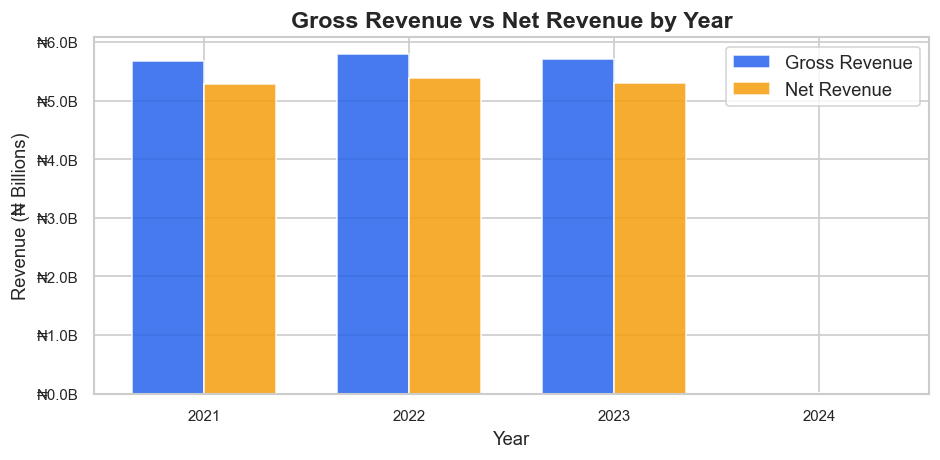

Fig saved: fig_gross_vs_net.png


In [10]:
# Visualise: Gross vs Net Revenue by year 
rev_by_year = df.groupby('year').agg(
    Gross=('gross_revenue', 'sum'),
    Net=('net_revenue', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(rev_by_year))
w = 0.35
ax.bar(x - w/2, rev_by_year['Gross'] / 1e9, w, label='Gross Revenue', color=BRAND_COLOR, alpha=0.85)
ax.bar(x + w/2, rev_by_year['Net'] / 1e9,   w, label='Net Revenue',   color=ACCENT_COLOR, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(rev_by_year['year'])
ax.set_xlabel('Year')
ax.set_ylabel('Revenue (₦ Billions)')
ax.set_title('Gross Revenue vs Net Revenue by Year')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₦{v:.1f}B'))
plt.tight_layout()
plt.savefig('fig_gross_vs_net.png', bbox_inches='tight')
plt.show()
print('Fig saved: fig_gross_vs_net.png')

---
## Task 4 — Monthly Revenue Trend (Line Chart, 2021–2023)

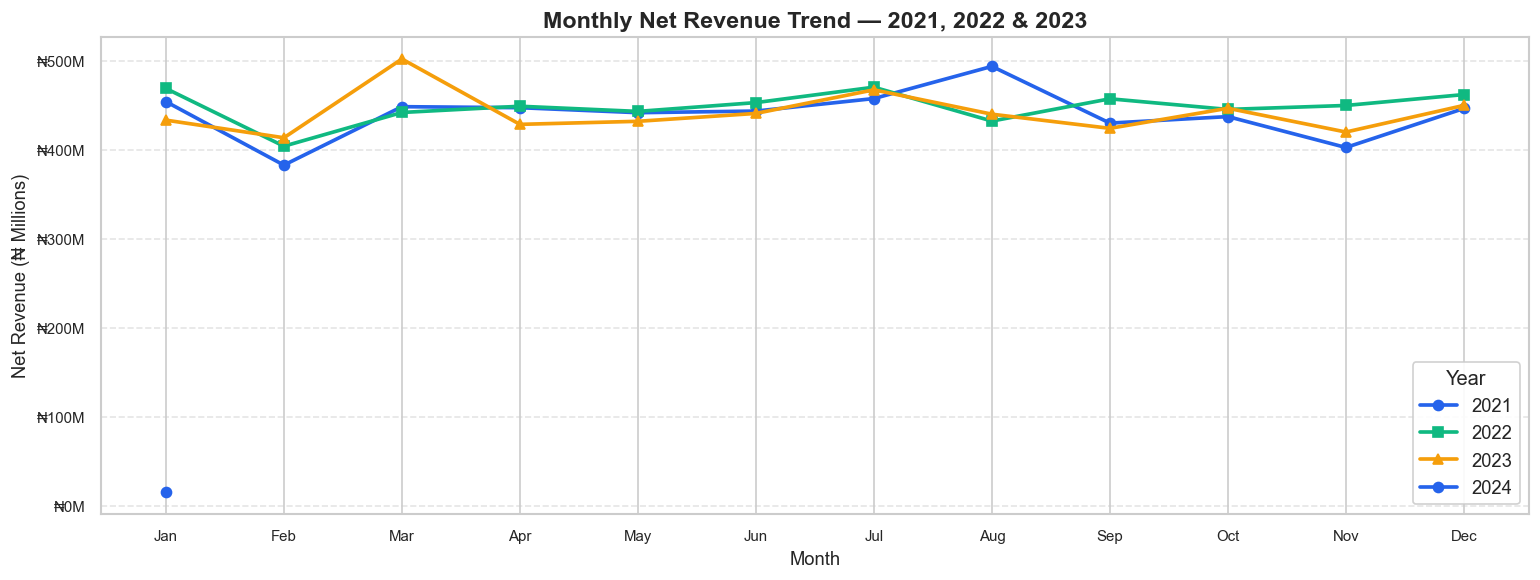

Fig saved: fig_monthly_trend.png


In [11]:
# ── Aggregate monthly revenue per year ──────────────────────────────────────
monthly = (
    df.groupby(['year', 'month'])['net_revenue']
      .sum()
      .reset_index()
)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(13, 5))
palette = ['#2563EB', '#10B981', '#F59E0B']  # blue, green, amber per year
markers = ['o', 's', '^']

for idx, yr in enumerate(sorted(monthly['year'].unique())):
    data = monthly[monthly['year'] == yr].sort_values('month')
    ax.plot(
        data['month'], data['net_revenue'] / 1e6,
        label=str(yr), color=palette[idx % len(palette)],
        linewidth=2.2, marker=markers[idx % len(markers)], markersize=6
    )

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_xlabel('Month')
ax.set_ylabel('Net Revenue (₦ Millions)')
ax.set_title('Monthly Net Revenue Trend — 2021, 2022 & 2023')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₦{v:.0f}M'))
ax.legend(title='Year', framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_monthly_trend.png', bbox_inches='tight')
plt.show()
print('Fig saved: fig_monthly_trend.png')

---
## Task 5 — Top 10 Products by Total Revenue (Bar Chart)

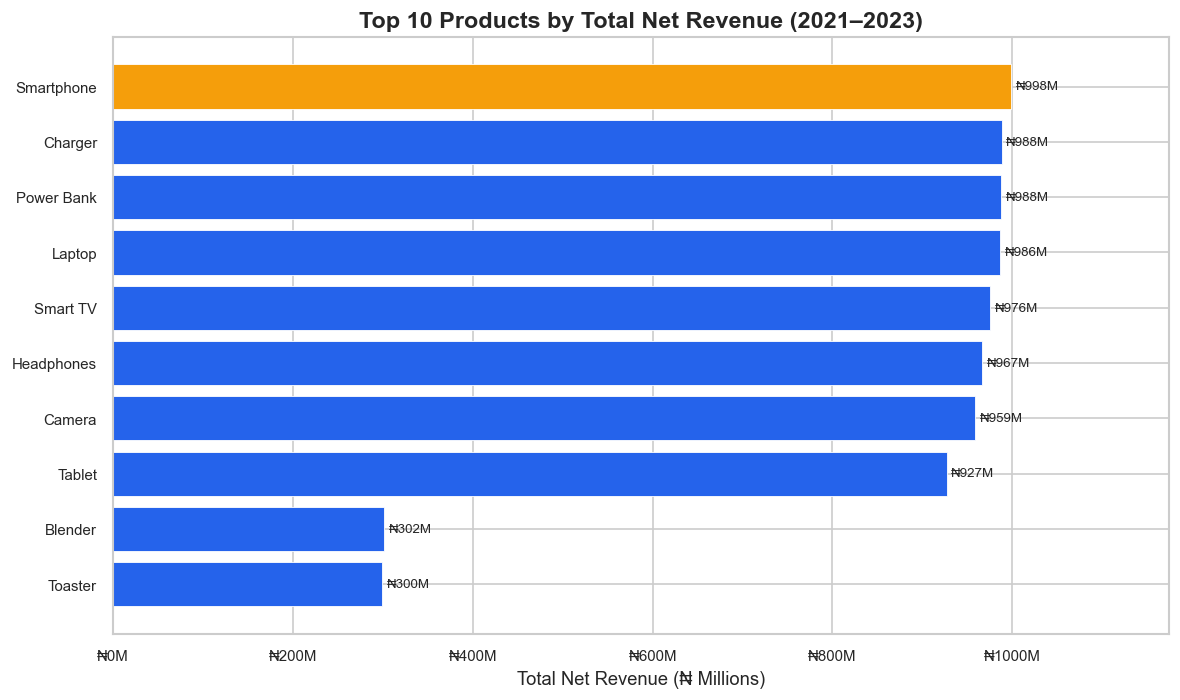

Fig saved: fig_top10_products.png


In [12]:
# Top 10 products 
top10_products = (
    df.groupby('product_name')['net_revenue']
      .sum()
      .nlargest(10)
      .sort_values()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [BRAND_COLOR if i < 9 else ACCENT_COLOR for i in range(10)]
bars = ax.barh(
    top10_products['product_name'],
    top10_products['net_revenue'] / 1e6,
    color=colors, edgecolor='white', linewidth=0.5
)

# Annotate bars
for bar in bars:
    w = bar.get_width()
    ax.text(w + 5, bar.get_y() + bar.get_height()/2,
            f'₦{w:.0f}M', va='center', ha='left', fontsize=8)

ax.set_xlabel('Total Net Revenue (₦ Millions)')
ax.set_title('Top 10 Products by Total Net Revenue (2021–2023)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₦{v:.0f}M'))
ax.set_xlim(right=ax.get_xlim()[1] * 1.12)
plt.tight_layout()
plt.savefig('fig_top10_products.png', bbox_inches='tight')
plt.show()
print('Fig saved: fig_top10_products.png')

---
## Task 6 — Return Rate by Product Category (Horizontal Bar Chart)

In [13]:
# Return rate = (returned orders / total orders) per category 
return_rate = (
    df.groupby('category')
      .apply(lambda g: (g['returned'] == 'Yes').sum() / len(g) * 100, include_groups=False)
      .rename('return_rate_pct')
      .sort_values()
      .reset_index()
)

print('Return Rate by Category:')
print(return_rate.to_string(index=False))

Return Rate by Category:
       category  return_rate_pct
 Home & Kitchen         7.378129
Health & Beauty         7.886155
           Toys         7.999190
Food & Beverage         8.106219
         Sports         8.131781
          Books         8.233890
    Electronics         8.235294
       Clothing         8.517820


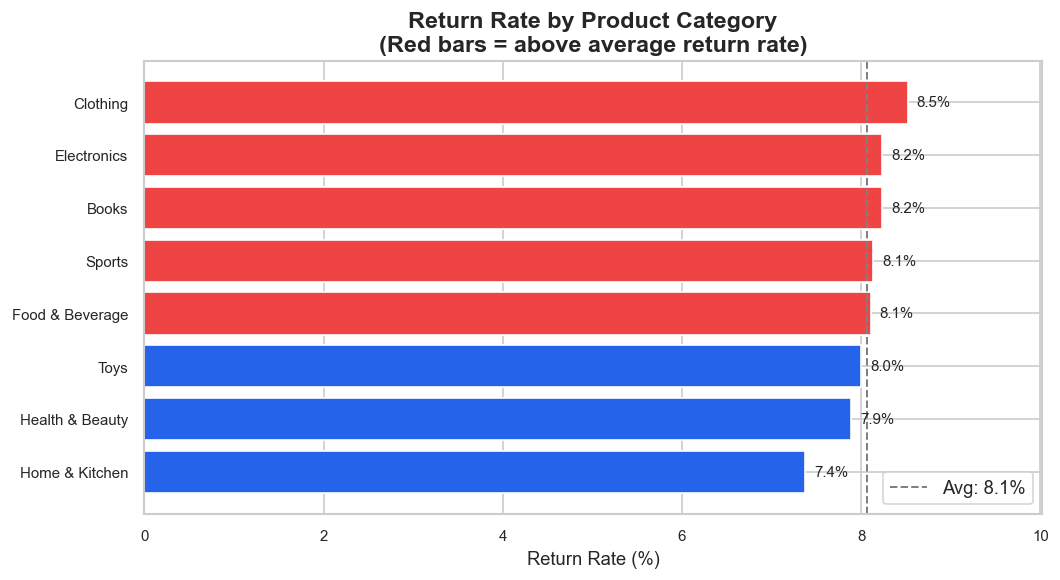

Fig saved: fig_return_rate_category.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [NEGATIVE_COLOR if v > return_rate['return_rate_pct'].mean() else BRAND_COLOR
              for v in return_rate['return_rate_pct']]

bars = ax.barh(
    return_rate['category'],
    return_rate['return_rate_pct'],
    color=bar_colors, edgecolor='white'
)

avg = return_rate['return_rate_pct'].mean()
ax.axvline(avg, color='grey', linestyle='--', linewidth=1.2, label=f'Avg: {avg:.1f}%')

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.1, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}%', va='center', ha='left', fontsize=9)

ax.set_xlabel('Return Rate (%)')
ax.set_title('Return Rate by Product Category\n(Red bars = above average return rate)')
ax.legend()
ax.set_xlim(right=ax.get_xlim()[1] * 1.12)
plt.tight_layout()
plt.savefig('fig_return_rate_category.png', bbox_inches='tight')
plt.show()
print('Fig saved: fig_return_rate_category.png')

---
## Task 7 — Payment Method Distribution (Donut Chart)

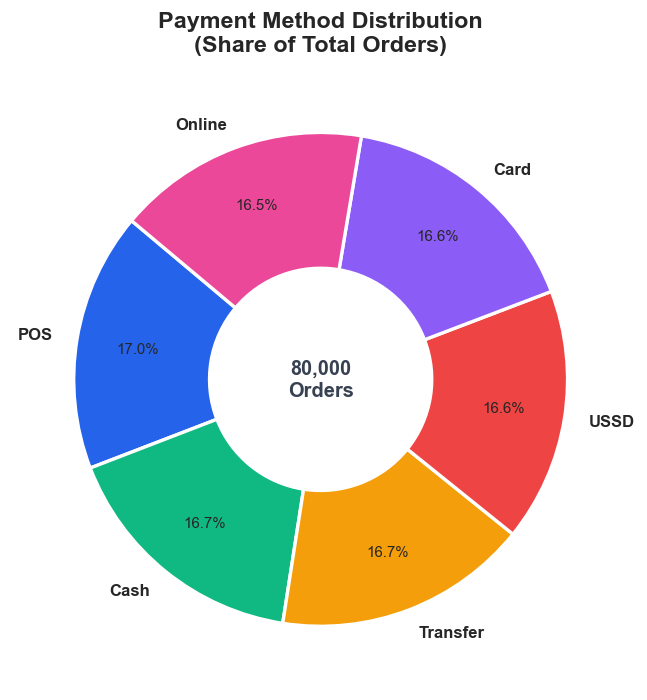

Fig saved: fig_payment_donut.png


In [15]:
# Payment method counts 
payment_counts = df['payment_method'].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
palette = ['#2563EB','#10B981','#F59E0B','#EF4444','#8B5CF6','#EC4899']

wedges, texts, autotexts = ax.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=palette,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance=0.75
)

for t in texts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
for at in autotexts:
    at.set_fontsize(9)

# Centre label
ax.text(0, 0, f'{df.shape[0]:,}\nOrders', ha='center', va='center',
        fontsize=12, fontweight='bold', color='#374151')

ax.set_title('Payment Method Distribution\n(Share of Total Orders)', pad=12)
plt.tight_layout()
plt.savefig('fig_payment_donut.png', bbox_inches='tight')
plt.show()
print('Fig saved: fig_payment_donut.png')

---
## Task 8 — Delivery Days vs Return Rate (Correlation & Scatter)

In [16]:
# Create a binary return flag 
df['returned_flag'] = (df['returned'] == 'Yes').astype(int)

# Aggregate by delivery_days bucket
# Bucket delivery days into ranges for cleaner analysis
df['delivery_bucket'] = pd.cut(
    df['delivery_days'],
    bins=[0, 3, 6, 9, 12, 15],
    labels=['1–3 days', '4–6 days', '7–9 days', '10–12 days', '13–15 days']
)

delivery_return = (
    df.groupby('delivery_bucket', observed=True)
      .agg(
          total_orders=('returned_flag', 'count'),
          returned=('returned_flag', 'sum')
      )
      .assign(return_rate_pct=lambda x: x['returned'] / x['total_orders'] * 100)
      .reset_index()
)

# Point-biserial correlation (delivery_days vs returned_flag) 
corr = df['delivery_days'].corr(df['returned_flag'])
print(f'Pearson correlation (delivery_days ↔ returned_flag): {corr:.4f}')
print()
print(delivery_return.to_string(index=False))

Pearson correlation (delivery_days ↔ returned_flag): 0.0009

delivery_bucket  total_orders  returned  return_rate_pct
       1–3 days         16978      1416         8.340205
       4–6 days         17273      1322         7.653563
       7–9 days         17014      1356         7.969907
     10–12 days         17331      1412         8.147251
     13–15 days         11404       944         8.277797


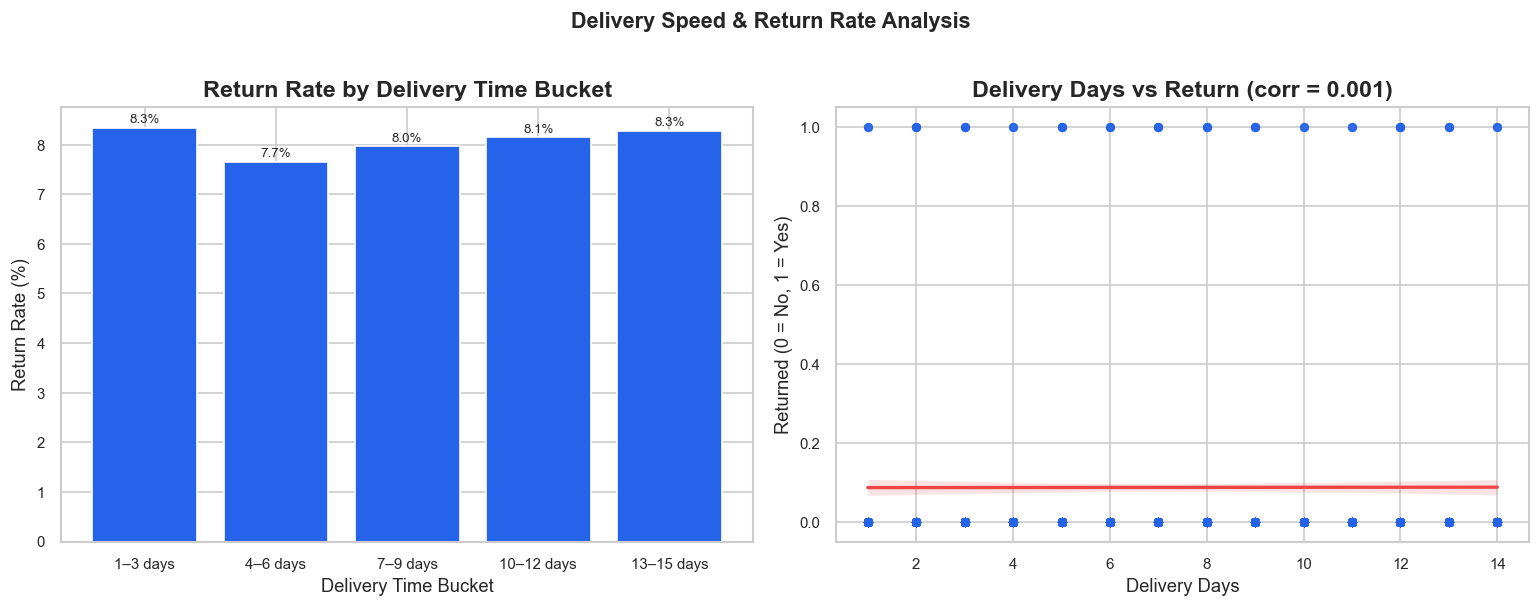

Fig saved: fig_delivery_vs_return.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Bar chart — return rate per delivery bucket
axes[0].bar(
    delivery_return['delivery_bucket'].astype(str),
    delivery_return['return_rate_pct'],
    color=BRAND_COLOR, edgecolor='white'
)
axes[0].set_xlabel('Delivery Time Bucket')
axes[0].set_ylabel('Return Rate (%)')
axes[0].set_title('Return Rate by Delivery Time Bucket')
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{bar.get_height():.1f}%',
        ha='center', fontsize=8
    )

# Right: Scatter plot (sampled) with regression line
sample = df.sample(3000, random_state=42)
sns.regplot(
    data=sample, x='delivery_days', y='returned_flag',
    ax=axes[1],
    scatter_kws=dict(alpha=0.15, color=BRAND_COLOR, s=20),
    line_kws=dict(color=NEGATIVE_COLOR, linewidth=2)
)
axes[1].set_xlabel('Delivery Days')
axes[1].set_ylabel('Returned (0 = No, 1 = Yes)')
axes[1].set_title(f'Delivery Days vs Return (corr = {corr:.3f})')

plt.suptitle('Delivery Speed & Return Rate Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_delivery_vs_return.png', bbox_inches='tight')
plt.show()
print('Fig saved: fig_delivery_vs_return.png')

---
## Task 9 — Heatmap: Average Revenue by Region and Category

In [18]:
# Pivot table: avg net_revenue per region × category 
heatmap_data = (
    df.groupby(['region', 'category'])['net_revenue']
      .mean()
      .unstack(fill_value=0)
)
heatmap_data = heatmap_data / 1_000  # convert to thousands for readability

print('Average Net Revenue (₦ thousands) — Region × Category')
heatmap_data.round(1)

Average Net Revenue (₦ thousands) — Region × Category


category,Books,Clothing,Electronics,Food & Beverage,Health & Beauty,Home & Kitchen,Sports,Toys
region,,,,,,,,
Abuja,54.3,121.0,783.3,46.9,81.5,231.3,184.6,93.3
Benin City,55.3,127.7,752.8,45.2,78.4,234.1,186.0,94.7
Enugu,55.2,121.2,792.7,47.5,73.8,231.6,185.4,94.6
Ibadan,55.7,126.8,770.7,46.5,79.9,239.4,191.3,91.9
Kaduna,54.9,123.9,785.1,45.5,75.3,237.7,185.4,93.4
Kano,53.4,130.0,793.8,45.7,78.2,234.9,187.9,92.2
Lagos,56.8,128.2,776.2,46.1,78.9,240.0,194.4,92.2
Port Harcourt,54.7,124.9,813.4,47.4,75.8,235.6,189.2,92.1


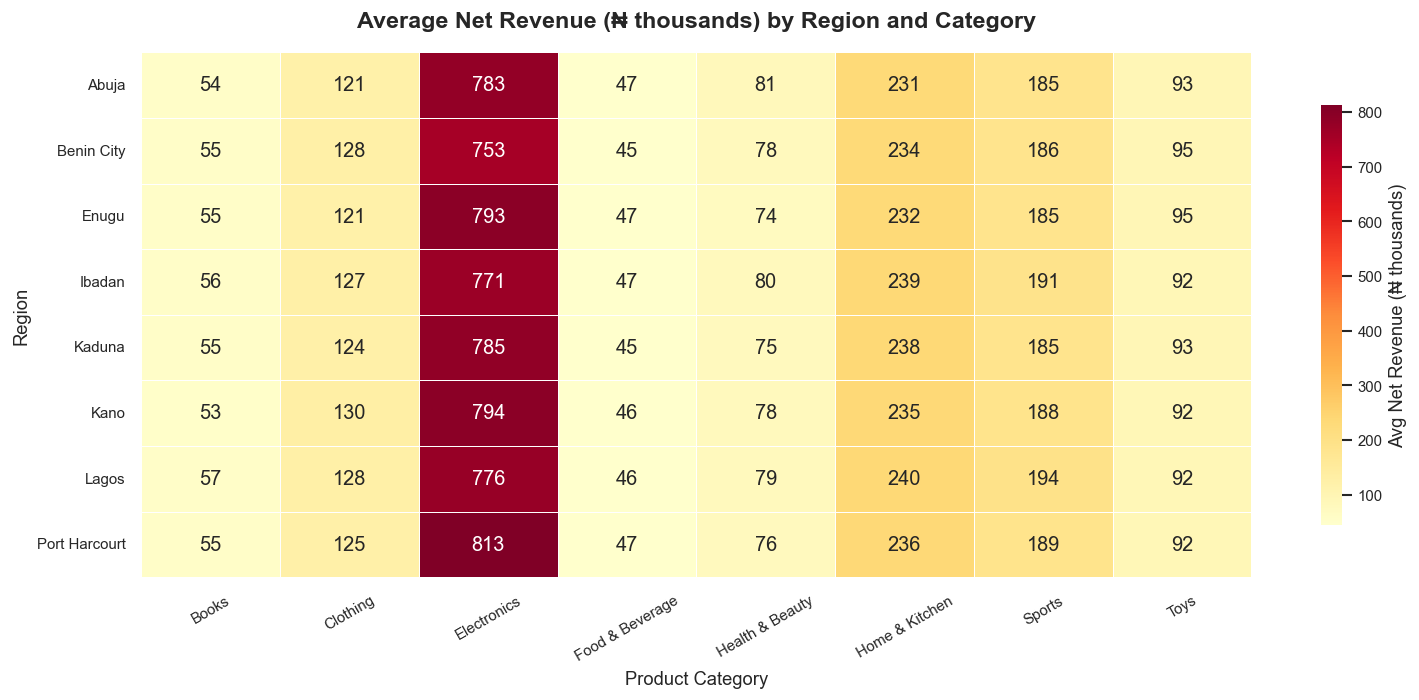

Fig saved: fig_heatmap_region_category.png


In [19]:
fig, ax = plt.subplots(figsize=(13, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Avg Net Revenue (₦ thousands)', 'shrink': 0.8}
)

ax.set_title('Average Net Revenue (₦ thousands) by Region and Category', pad=15)
ax.set_xlabel('Product Category')
ax.set_ylabel('Region')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('fig_heatmap_region_category.png', bbox_inches='tight')
plt.show()
print('Fig saved: fig_heatmap_region_category.png')

---
## Bonus Chart — Revenue by Region (Supporting Regional Analysis)

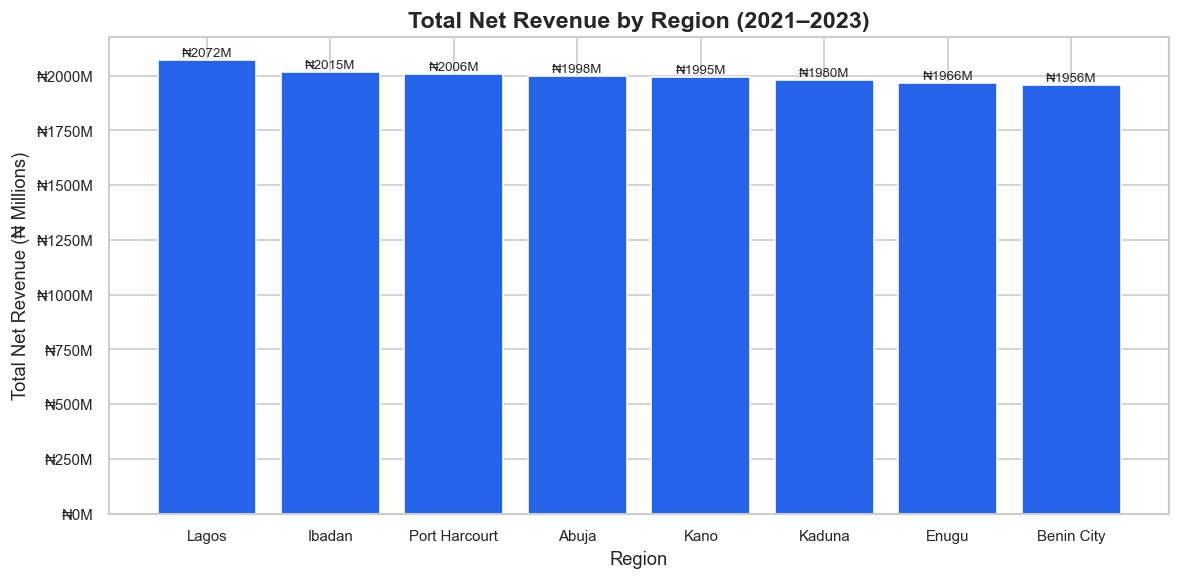

Fig saved: fig_revenue_by_region.png


In [20]:
# Total revenue and order count by region
region_summary = (
    df.groupby('region')
      .agg(
          total_revenue=('net_revenue', 'sum'),
          order_count=('order_id', 'count'),
          return_rate=('returned_flag', 'mean')
      )
      .sort_values('total_revenue', ascending=False)
      .reset_index()
)
region_summary['total_revenue_M'] = region_summary['total_revenue'] / 1e6

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    region_summary['region'],
    region_summary['total_revenue_M'],
    color=BRAND_COLOR, edgecolor='white'
)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 5,
            f'₦{h:.0f}M', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Region')
ax.set_ylabel('Total Net Revenue (₦ Millions)')
ax.set_title('Total Net Revenue by Region (2021–2023)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₦{v:.0f}M'))
plt.tight_layout()
plt.savefig('fig_revenue_by_region.png', bbox_inches='tight')
plt.show()
print('Fig saved: fig_revenue_by_region.png')

In [21]:
# ── Summary statistics print-out ───────────────────────────────────────────────
print('=' * 60)
print('  EXECUTIVE SUMMARY — KEY METRICS')
print('=' * 60)
print(f"  Total Orders       : {len(df):,}")
print(f"  Total Net Revenue  : ₦{df['net_revenue'].sum():,.0f}")
print(f"  Avg Order Value    : ₦{df['net_revenue'].mean():,.0f}")
print(f"  Overall Return Rate: {df['returned_flag'].mean()*100:.1f}%")
print(f"  Total Discounts    : ₦{df['discount_amount'].sum():,.0f}")
print(f"  Unique Products    : {df['product_name'].nunique()}")
print(f"  Unique Customers   : {df['customer_id'].nunique():,}")
print(f"  Regions            : {df['region'].nunique()} cities")
print(f"  Date Range         : {df['order_date'].min().date()} → {df['order_date'].max().date()}")
print('=' * 60)

  EXECUTIVE SUMMARY — KEY METRICS
  Total Orders       : 80,000
  Total Net Revenue  : ₦15,987,954,070
  Avg Order Value    : ₦199,849
  Overall Return Rate: 8.1%
  Total Discounts    : ₦1,206,201,330
  Unique Products    : 64
  Unique Customers   : 18,716
  Regions            : 8 cities
  Date Range         : 2021-01-01 → 2024-01-01
